# Deep Learning Examples

**Note: Run this notebook in Google Colab for best compatibility.**

This notebook demonstrates neural networks and transformers using TensorFlow/Keras and Hugging Face.


## 1. Three-Layer Neural Network


### 1.1 Data Loading


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape((x_train.shape[0], 28 * 28))
x_test = x_test.reshape((x_test.shape[0], 28 * 28))

print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Feature dimensions: {x_train.shape[1]}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000
Feature dimensions: 784


### 1.2 Model Architecture


In [2]:
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

### 1.3 Training


In [3]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9261 - loss: 0.2524 - val_accuracy: 0.9643 - val_loss: 0.1176
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9728 - loss: 0.0901 - val_accuracy: 0.9737 - val_loss: 0.0891
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9830 - loss: 0.0557 - val_accuracy: 0.9747 - val_loss: 0.0847
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9885 - loss: 0.0380 - val_accuracy: 0.9770 - val_loss: 0.0829
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9902 - loss: 0.0308 - val_accuracy: 0.9751 - val_loss: 0.0922
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9763 - val_loss: 0.0963
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9948 - loss: 0.0155 - val_accuracy: 0.9779 - val_loss: 0.0936
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9941 - loss: 0.0175 - val_acc

### 1.4 Evaluation


Test accuracy: 0.9827
Test loss: 0.0750


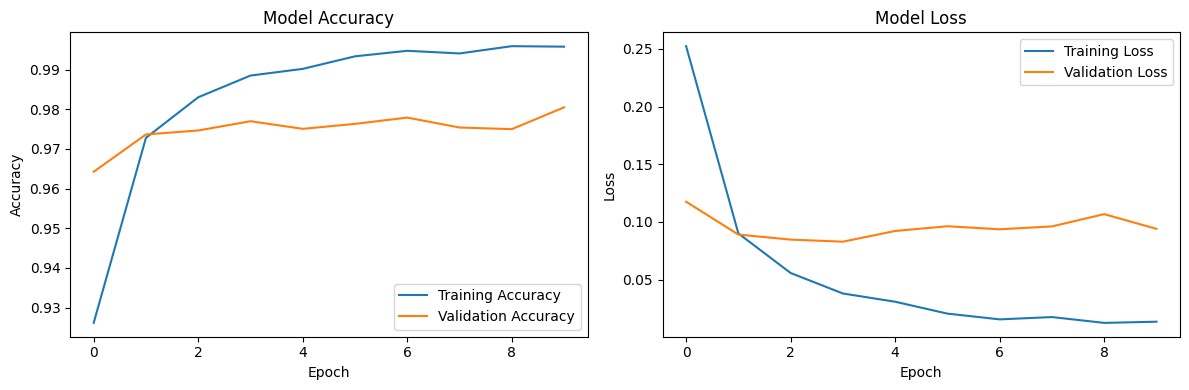

In [4]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.tight_layout()
plt.show()


## 2. Transformer for Zero-Shot Sentiment Classification


### 2.1 Setup and Model Loading


In [ ]:
!pip install transformers torch


In [ ]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", 
                     model="facebook/bart-large-mnli")


### 2.2 Zero-Shot Classification Examples


In [ ]:
candidate_labels = ["positive", "negative", "neutral"]

text1 = "I absolutely love this product! It's amazing!"
result1 = classifier(text1, candidate_labels)
print(f"Text: {text1}")
print(f"Labels: {result1['labels']}")
print(f"Scores: {result1['scores']}")
print()


In [ ]:
text2 = "This is the worst experience I've ever had."
result2 = classifier(text2, candidate_labels)
print(f"Text: {text2}")
print(f"Labels: {result2['labels']}")
print(f"Scores: {result2['scores']}")
print()


In [ ]:
text3 = "The weather is okay today, nothing special."
result3 = classifier(text3, candidate_labels)
print(f"Text: {text3}")
print(f"Labels: {result3['labels']}")
print(f"Scores: {result3['scores']}")
print()


### 2.3 Batch Classification


In [ ]:
texts = [
    "This movie is fantastic!",
    "I hate waiting in long lines.",
    "The service was acceptable.",
    "Best purchase I've made this year!",
    "Terrible quality, very disappointed."
]

results = classifier(texts, candidate_labels)

for i, (text, result) in enumerate(zip(texts, results)):
    print(f"Text {i+1}: {text}")
    print(f"Predicted: {result['labels'][0]} (score: {result['scores'][0]:.4f})")
    print()
